# CH6 多變數圖表（Multivariate Plots）

## 簡介  
多變數圖表用於同時呈現三個以上變數之間的關係，透過顏色、大小、形狀、分面等視覺編碼方式，使資料的多維特性得以清晰呈現。這類圖表有助於探索變數交互關係、群體差異以及模式辨識。以下將介紹的圖表包括：  
- 氣泡圖（Bubble Chart）  
- 分面圖（Facet Grid）  
- 成對變數矩陣圖（Pair Plot）  
- 平行座標圖（Parallel Coordinates）


## 6.1 氣泡圖（Bubble Chart）

### 1. 定義  
氣泡圖是基於散佈圖衍生出的視覺化方式，除了用 X 軸和 Y 軸呈現兩個數值變數外，還利用氣泡的大小（size）及/或顏色（hue）來表示第三或第四個變數。此圖表適合呈現高維資料特徵與不同群體的差異。

---

### 2. 範例圖表與說明  

<div align="center">  
  <img src="https://raw.githubusercontent.com/jacklin92/ch6/main/BubbleChart.png" width="400">
</div>

**觀察與解釋**：  
- X 軸代表年齡（Age），Y 軸代表 BMI  
- 氣泡大小表示住院天數（Days Hospitalized）：住院天數越多，氣泡越大  
- 氣泡顏色用於區分性別（Gender）；例如：男性以藍色（skyblue）、女性以淡珊瑚紅（lightcoral）表示  
- 從圖中可見，較高年齡的病患通常有較大的氣泡，暗示住院天數較長

---

### 3. 適用情況  
- 同時顯示三個或以上數值變數的信息  
- 分析各變數間的關聯性與群聚結構  
- 快速辨識出極值及異常情況

---

### 4. 優缺點  
- **優點**：  
  - 一張圖可呈現 3-4 維資料資訊，直觀豐富  
  - 氣泡的大小與顏色能有效輔助分類與比較  
- **缺點**：  
  - 氣泡大小感知不精確，難以精確比較比例  
  - 當資料量過多時，氣泡重疊容易造成視覺混亂

---

### 5. 實際案例與圖表  
- **醫療領域**：利用氣泡圖分析病患年齡、BMI 與住院天數，並依性別區分  
- **電子商務**：以氣泡圖比較不同產品類別的價格、銷量與廣告投放數量  
- **製造領域**：呈現設備運轉時數、故障次數與產量，輔以不同工廠分組


### 6. 實作範例：醫學領域 - 年齡、BMI 與住院天數關聯分析（Bubble Chart）

#### 資料說明  
模擬 200 筆病患資料，包含以下欄位：  
- **Age**：Patient Age (整數，20～80 歲)  
- **BMI**：Body Mass Index (浮點數，平均約 24，標準差約 4)  
- **Days_Hospitalized**：Days Hospitalized (住院天數，以 Poisson 分布模擬，平均約 5 天)  
- **Gender**：Gender (性別，"Male" 或 "Female")  

📥 [下載資料集：`patient_bubble_data.csv`](sandbox:/mnt/data/patient_bubble_data.csv)


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH6_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH6_dataset/images'

Mounted at /content/drive


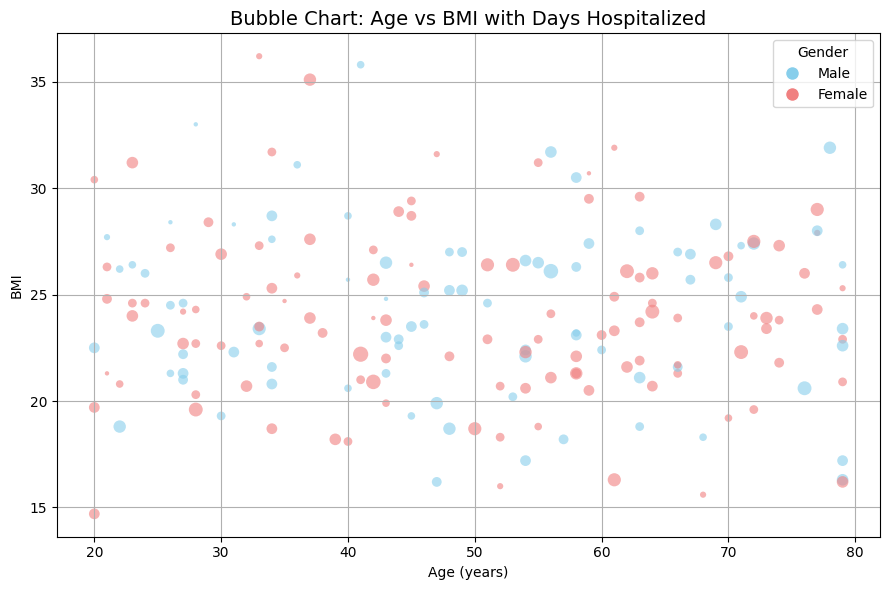

In [3]:
# 匯入所需函式庫
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 載入資料集
from pathlib import Path

data_file = "patient_bubble_data.csv"
df = pd.read_csv(path+"/"+data_file)

# 定義性別對應顏色的對照表
color_map = {"Male": "skyblue", "Female": "lightcoral"}
# 根據性別欄位轉換為對應顏色
colors = df["Gender"].map(color_map)

# 建立圖表並設定尺寸
plt.figure(figsize=(9, 6))

# 繪製氣泡圖：
# X 軸：年齡（Age）
# Y 軸：BMI
# 氣泡大小：住院天數（Days_Hospitalized）乘以 10 放大
plt.scatter(
    df["Age"],
    df["BMI"],
    s=df["Days_Hospitalized"] * 10,
    c=colors,
    alpha=0.6,       # 設定氣泡透明度
    edgecolors="none",  # 無邊框
    marker='o'       # 使用實心圓形
)

# 加入標題與軸標籤
plt.title("Bubble Chart: Age vs BMI with Days Hospitalized", fontsize=14)
plt.xlabel("Age (years)")
plt.ylabel("BMI")
plt.grid(True)

# 建立自訂圖例：使用圓形與指定顏色
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Male',
           markerfacecolor='skyblue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Female',
           markerfacecolor='lightcoral', markersize=10)
]
plt.legend(handles=legend_elements, title="Gender")

# 調整版面與顯示圖表
plt.tight_layout()


### Try it!：實作範例：醫學領域 - 年齡、BMI 與住院天數關聯分析（Bubble Chart）
把住院天數分成短、中、長三級後上色，觀察長住病患集中在哪些年齡與 BMI 區間。

**程式要求**
1. 讀取 `datasets/patient_bubble_data.csv`，用 `pd.cut` 建立 `Stay_Level` 欄位：3 天以下為 `Short`、3 到 7 天為 `Medium`、超過 7 天為 `Long`，並印出各級人數。
2. 繪製氣泡圖並依 `Stay_Level` 分色（綠、橘、紅）。
3. 加上圖例、標題與軸標籤。

#### 📌 補充參數與設定說明

| 參數         | 說明                                         | 建議範例值                                  |
|--------------|----------------------------------------------|---------------------------------------------|
| `s`          | 氣泡大小                                      | `Days_Hospitalized * 10` （可調整倍率）       |
| `c`          | 氣泡顏色                                      | 可用色碼或顏色名稱（例如 "skyblue", "lightcoral"） |
| `alpha`      | 透明度                                        | 0.4, 0.6, 0.8                               |
| `edgecolors` | 氣泡邊框顏色                                  | "w" (白色) 或 "black"                        |
| `linewidth`  | 邊框線條寬度                                  | 0.5, 1.0                                    |


#### 📝 練習任務建議

1. **任務一**：調整氣泡大小比例（例如將 `s = Days_Hospitalized * 5` 或 `*20`），比較圖表的可讀性與美觀度。  
2. **任務二**：嘗試不同顏色設定，例如利用其他調色盤或改用 HEX 色碼（例如 `"#FF5733"` 等）以提高視覺對比。  
3. **任務三**：使用 Seaborn 的 `sns.scatterplot()` 重寫氣泡圖，檢查效果差異。  
4. **任務四**：新增第四個變數（例如 Severity）並用 `alpha` 或點形狀來表示。  
5. **任務五**：修改圖例設置（例如使用 `plt.legend()` 調整位置與標題）以完善說明框。
